Missing Values in Fraud Data:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Missing Values in Credit Card Data:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Missing Values in IP to Country:
 lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64
Credit Card Data Shape after removing duplicates: (283726, 31)


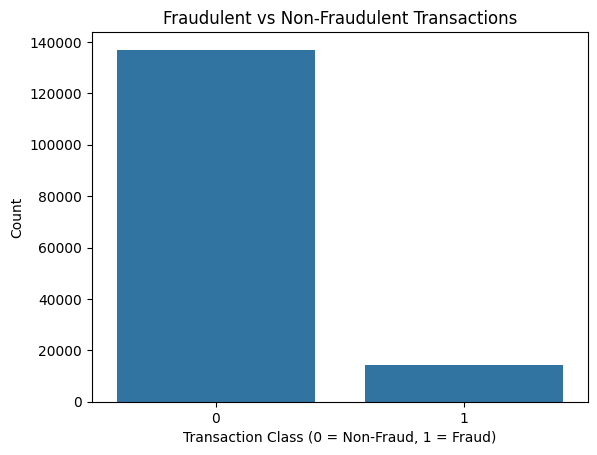

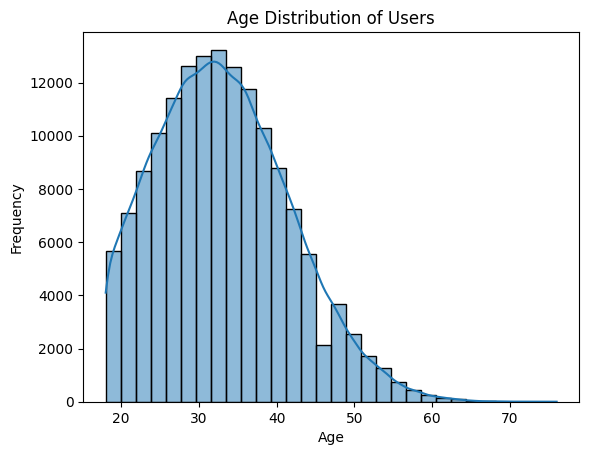

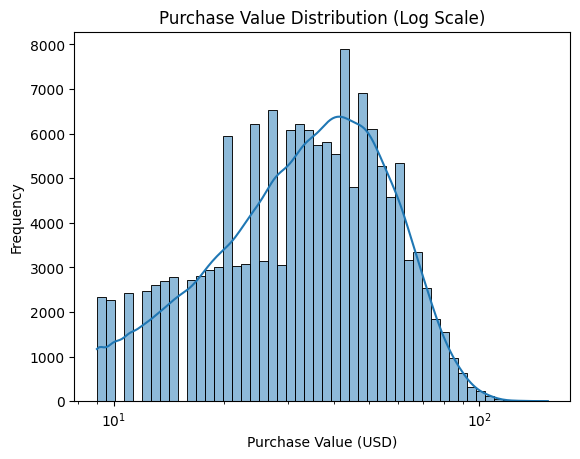

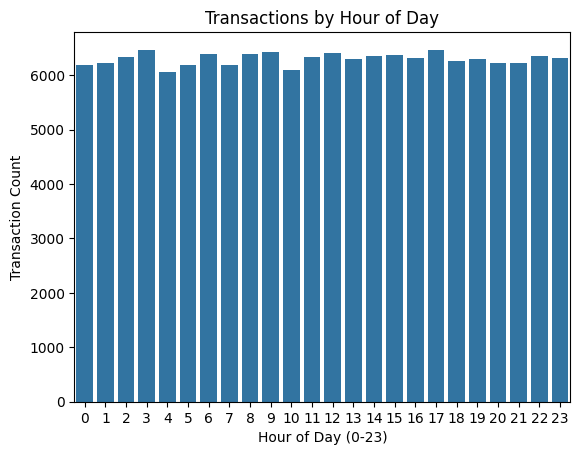

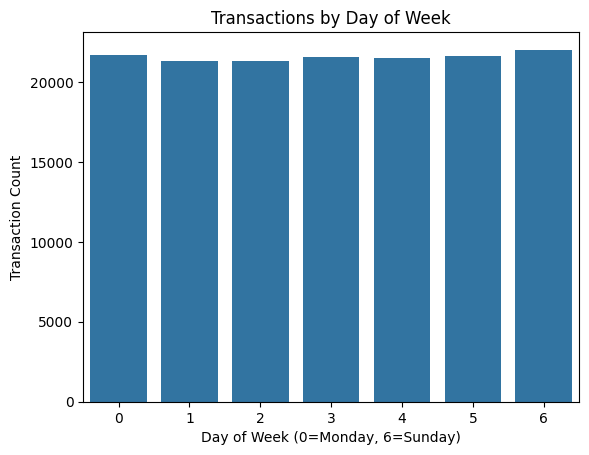

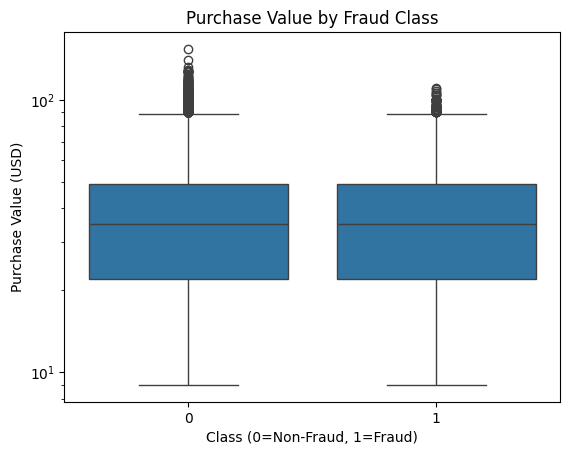

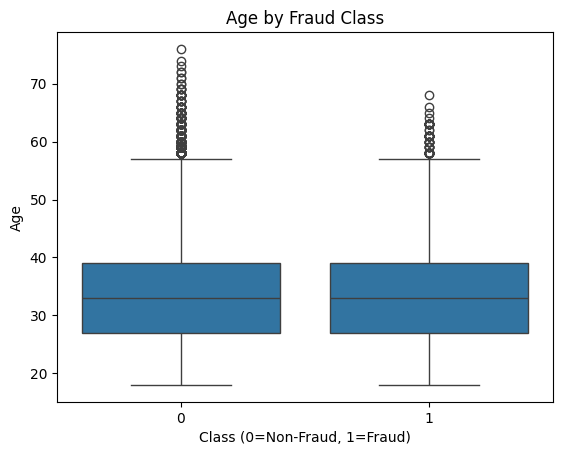

Class distribution after SMOTE:
 class
0    136961
1    136961
Name: count, dtype: int64
Shape of scaled feature set: (273922, 12)


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


# Load Data
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
credit_card_data = pd.read_csv('../data/raw/creditcard.csv')


# 1. Handle Missing Values
print("Missing Values in Fraud Data:\n", fraud_data.isnull().sum())
print("Missing Values in Credit Card Data:\n", credit_card_data.isnull().sum())
print("Missing Values in IP to Country:\n", ip_country.isnull().sum())


# 2. Data Cleaning
# Drop duplicates in Credit Card Data
credit_card_data.drop_duplicates(inplace=True)
print("Credit Card Data Shape after removing duplicates:", credit_card_data.shape)

# Convert signup_time and purchase_time to datetime
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])


# 3. Exploratory Data Analysis (EDA)

# Class distribution
sns.countplot(x='class', data=fraud_data)
plt.title('Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Transaction Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

# Age distribution
sns.histplot(fraud_data['age'], bins=30, kde=True)
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Purchase value distribution (log scale)
sns.histplot(fraud_data['purchase_value'], bins=50, kde=True, log_scale=True)
plt.title('Purchase Value Distribution (Log Scale)')
plt.xlabel('Purchase Value (USD)')
plt.ylabel('Frequency')
plt.show()

# Transactions by Hour of Day
sns.countplot(x='hour_of_day', data=fraud_data.assign(hour_of_day=fraud_data['purchase_time'].dt.hour))
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Transaction Count')
plt.show()

# Transactions by Day of Week
sns.countplot(x='day_of_week', data=fraud_data.assign(day_of_week=fraud_data['purchase_time'].dt.dayofweek))
plt.title('Transactions by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Transaction Count')
plt.show()

# Purchase Value by Fraud Class
sns.boxplot(x='class', y='purchase_value', data=fraud_data)
plt.title('Purchase Value by Fraud Class')
plt.xlabel('Class (0=Non-Fraud, 1=Fraud)')
plt.ylabel('Purchase Value (USD)')
plt.yscale('log')
plt.show()

# Age by Fraud Class
sns.boxplot(x='class', y='age', data=fraud_data)
plt.title('Age by Fraud Class')
plt.xlabel('Class (0=Non-Fraud, 1=Fraud)')
plt.ylabel('Age')
plt.show()


# 4. Merge Datasets for Geolocation Analysis
# Create IntervalIndex from IP ranges
ip_intervals = pd.IntervalIndex.from_arrays(
    ip_country['lower_bound_ip_address'],
    ip_country['upper_bound_ip_address'],
    closed='both'
)

# Function to map IP to country
def get_country(ip):
    idx = ip_intervals.get_indexer([ip])[0]
    if idx == -1:
        return 'Unknown'
    else:
        return ip_country.iloc[idx]['country']

# Map countries
fraud_data['country'] = fraud_data['ip_address'].apply(get_country)


# 5. Feature Engineering
# Add transaction counts (if user_id/device_id exist)
if 'user_id' in fraud_data.columns and 'device_id' in fraud_data.columns:
    fraud_data['user_tx_count'] = fraud_data.groupby('user_id')['purchase_time'].transform('count')
    fraud_data['device_tx_count'] = fraud_data.groupby('device_id')['purchase_time'].transform('count')
    fraud_data.drop(['user_id', 'device_id'], axis=1, inplace=True)

# Time-based features
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()

# Label encode categorical columns
categorical_cols = ['browser', 'source', 'sex', 'country']
le = LabelEncoder()
for col in categorical_cols:
    fraud_data[col] = le.fit_transform(fraud_data[col])

# Drop datetime columns
fraud_data.drop(['signup_time', 'purchase_time'], axis=1, inplace=True)


# 6. Data Transformation (SMOTE + Scaling)
X_fraud_prepared = fraud_data.drop('class', axis=1)
y_fraud = fraud_data['class']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_fraud_prepared, y_fraud)

print("Class distribution after SMOTE:\n", pd.Series(y_resampled).value_counts())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

print("Shape of scaled feature set:", X_scaled.shape)